The aim of this notebook is to be able to develop an augmented reality (AR) video, using two source videos. The first video shows two books: Computer Vision (A Modern Approach) and Multiple View Geometry (in computer vision). The second video is the trailer of the animated movie: Kung Fu Panda.

**TASK**

The aim of this task is to be able to overlay every frame of the Kung Fu Panda movie over the Computer Vision book in the second movie.

In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# SIFT function performing the SIFT Descriptor
def SIFT(img):
  # Instantiate SIFT object
  sift = cv2.SIFT_create()
  keypoints, descriptors = sift.detectAndCompute(img, None)
  image_detected_blobs = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
  return image_detected_blobs, keypoints, descriptors


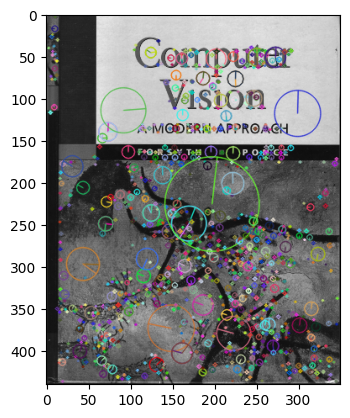

In [105]:
# Reading input image (Book cover)
image = cv2.imread('cv_cover.jpg')
img_grayscale = cv2.imread('cv_cover.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# SIFT Outcome plotted
sift_outcome = SIFT(img_grayscale)
image_detected_blobs_A = sift_outcome[0]
keypoints_A = sift_outcome[1]
descriptors_A = sift_outcome[2]
plt.imshow(image_detected_blobs_A)

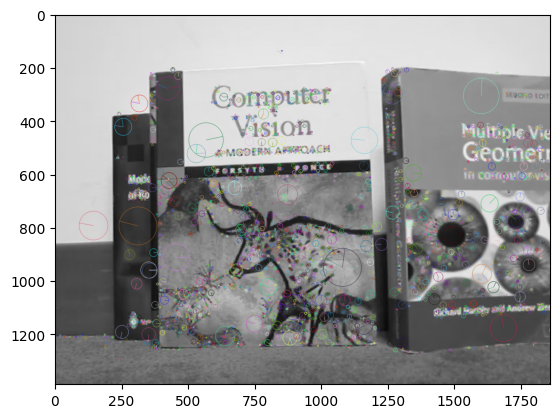

In [106]:
# Reading input image (Book cover -- first frame in the first movie)
image_movie = cv2.imread('cv_cover_movie.jpg')
img_grayscale_movie = cv2.imread('cv_cover_movie.jpg', cv2.IMREAD_GRAYSCALE)
img_movie = cv2.cvtColor(image_movie, cv2.COLOR_BGR2RGB)
# SIFT Outcome plotted
sift_outcome_movie = SIFT(img_grayscale_movie)
image_detected_blobs_B = sift_outcome_movie[0]
keypoints_B = sift_outcome_movie[1]
descriptors_B = sift_outcome_movie[2]
plt.imshow(image_detected_blobs_B)

In [81]:
# Brute force function. Matcher used to obtain the correspondances between images
def brute_force(image_A, image_keypoints_A ,image_descriptors_A, image_B, image_keypoints_B ,image_descriptors_B):
  brute_force_matcher = cv2.BFMatcher()
  # K Nearest Neighbors, Neighbors = 2
  neighbors = 2
  matches = brute_force_matcher.knnMatch(image_descriptors_A, image_descriptors_B, neighbors)
  # Select only good matches according to ratio. According to Lowe's paper, a match with ratio of 0.65 is a good match
  ratio = 0.65
  good_matches = []
  for m, n in matches:
    if m.distance < ratio*n.distance:
      good_matches.append([m])
  number_of_matches = 50
  good_matches = sorted(good_matches, key=lambda x:x[0].distance)
  good_matches = good_matches[:number_of_matches]
  image_with_matches = cv2.drawMatchesKnn(image_A, image_keypoints_A, image_B, image_keypoints_B, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
  return image_with_matches, good_matches

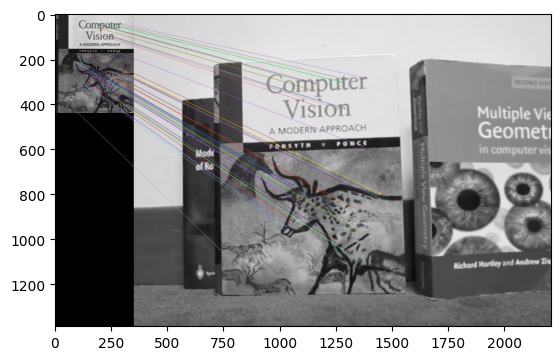

In [82]:
# Brute force matcher outcome
brute_force_outcome = brute_force(img_grayscale, keypoints_A, descriptors_A, img_grayscale_movie, keypoints_B, descriptors_B)
plt.imshow(brute_force_outcome[0])


In [83]:
# Computing the homography parameters
def compute_homography(matches, keypoints_A, keypoints_B):
  # Compute correspondences first. Find pairs of x and y values.
  # Pairs must be correctly aligned.
  # Correspondences between 'cv_cover.jpg' and 'cv_cover_movie.jpg'
  points_A = np.zeros((len(matches), 2), dtype=np.float32)
  points_B = np.zeros((len(matches), 2), dtype=np.float32)
  for i, match in enumerate(matches):
    m = match[0]
    points_A[i, :] = keypoints_A[m.queryIdx].pt
    points_B[i, :] = keypoints_B[m.trainIdx].pt
  # Finding the homography matrix through solving a system of equations. Each correspondences (x,y) provides 2 equations
  # 8 unknowns in H are stacked on top of one another, 9th term (3,3) is set to 1
  # To find the 8 unknowns, we need at least 4 correspondences.
  # Solving Ah = 0. h contains all 8 unknown homography parameters stacked on top of each other.
  # A is a 2n * 9 matrix, n being the number of correspondences.

  A = np.zeros((2*len(points_A), 9), dtype=np.float32)
  for i in range(0,15):
    A[2*i, :] = [-points_A[i, 0], -points_A[i, 1], -1, 0, 0, 0, points_B[i, 0]*points_A[i, 0], points_B[i, 0]*points_A[i, 1], points_B[i, 0]]
    A[2*i+1, :] = [0, 0, 0, -points_A[i, 0], -points_A[i, 1], -1, points_B[i, 1]*points_A[i, 0], points_B[i, 1]*points_A[i, 1], points_B[i, 1]]
    # Singular Value Decomposition for the matrix A
  U, S, V = np.linalg.svd(A)
  # Store the singular vector of the smallest singular value
  smallest_signular_vector = V[-1, :]
  # Reshape to get H
  H = smallest_signular_vector.reshape(3, 3)
  H = H / H[-1, -1]

  return H, points_A, points_B

Calculated H:
 [[ 2.2527812e+00 -1.6869664e-03  3.4323886e+02]
 [-1.4739183e-01  2.2565856e+00  2.2138458e+02]
 [-9.0668000e-05 -8.8932706e-05  1.0000000e+00]]
H from Builtin Function:
 [[ 2.24801239e+00  4.26682070e-03  3.43596853e+02]
 [-1.51949976e-01  2.26131373e+00  2.21916633e+02]
 [-9.47724954e-05 -8.16425763e-05  1.00000000e+00]]


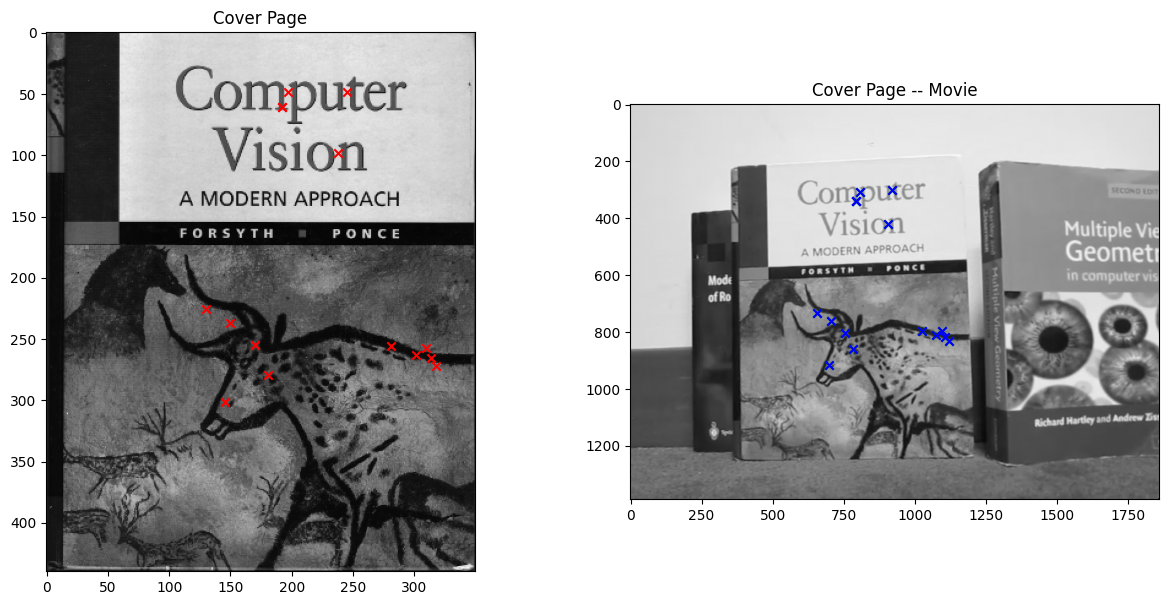

In [84]:
H, points_A, points_B =compute_homography(brute_force_outcome[1], keypoints_A, keypoints_B)

H_built_in, _ = cv2.findHomography(points_A, points_B, 0)

print('Calculated H:\n',H)
print('H from Builtin Function:\n', H_built_in)

# Testing the validity of the computed H matrix
# Testing on the first 10 correspondences between A and B
A_image_points = []
B_image_points = []
estimated_image_points = []
for i in range(15):
  x_A = points_A[i, 0]
  y_A = points_A[i, 1]
  A_image_points.append([x_A, y_A])
  x_B = points_B[i, 0]
  y_B = points_B[i, 1]
  B_image_points.append([x_B, y_B])
  # Transform to homogeneous coordinates (A --> input), (B --> ground truth)
  point_A_homogeneous = np.array([points_A[i, 0], points_A[i, 1], 1])
  # Homography output (estimated)
  point_B_homogeneous_esitimated = np.dot(H, point_A_homogeneous)
  # homogeneous --> heterogeneous again
  w_estimated = point_B_homogeneous_esitimated[2]
  y_estimated = point_B_homogeneous_esitimated[1] / w_estimated
  x_estimated = point_B_homogeneous_esitimated[0] / w_estimated
  estimated_image_points.append([x_estimated, y_estimated])

A_points = np.array(A_image_points)
B_points = np.array(B_image_points)
estimated_points = np.array(estimated_image_points)

# Making images appear side by side
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.imshow(img_grayscale, cmap='gray')
ax1.scatter(A_points[:,0], A_points[:,1], c='r', marker='x')
ax1.set_title('Cover Page')

ax2.imshow(img_grayscale_movie, cmap='gray')
ax2.scatter(estimated_points[:,0], estimated_points[:,1], c='g', marker='x')
ax2.scatter(B_points[:,0], B_points[:,1], c='b', marker='x')
ax2.set_title('Cover Page -- Movie')

plt.show()




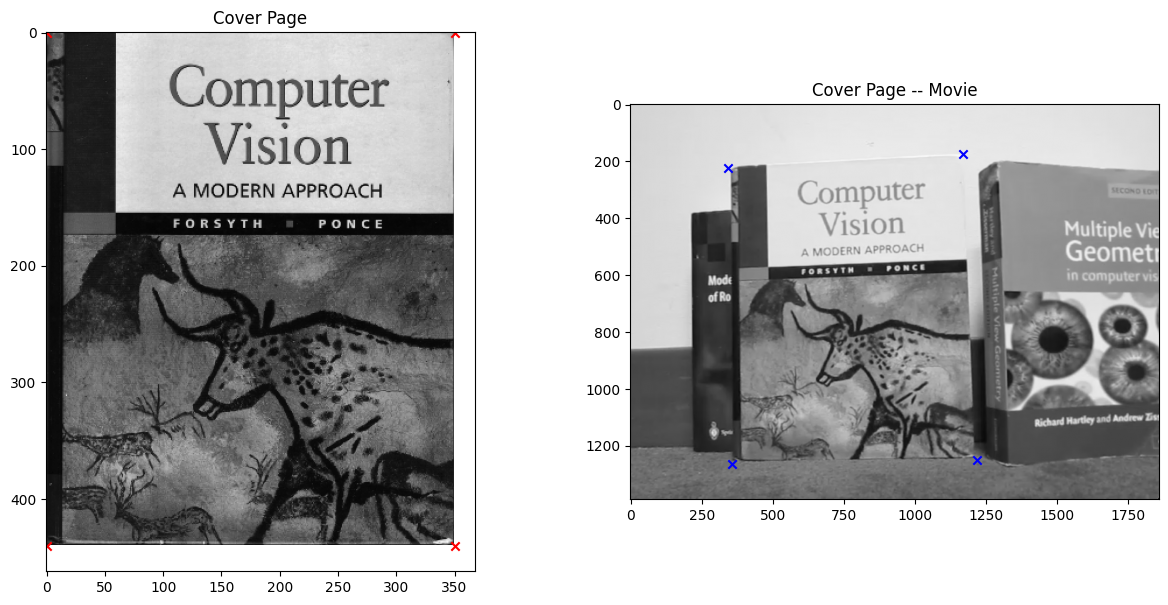

In [119]:
# Mapping the corners of the book's cover to the book's cover in the movie
# Four corners are found at [0,440], [0,0], [350,0], [350,440]
def detect_corners_from_homography(H):
  corners = [[0,440], [0,0], [350,0], [350,440]]
  corners_estimated = []

  for i in range(len(corners)):
    point_homogeneous = np.array([corners[i][0], corners[i][1], 1])
    point_homogeneous_estimated = np.dot(H, point_homogeneous)
    w_estimated = point_homogeneous_estimated[2]
    y_estimated = point_homogeneous_estimated[1] / w_estimated
    x_estimated = point_homogeneous_estimated[0] / w_estimated
    corners_estimated.append([x_estimated, y_estimated])

  corners_estimated = np.array(corners_estimated)
  corners = np.array(corners)
  return corners, corners_estimated
corners, corners_estimated = detect_corners_from_homography(H)
# Making images appear side by side
figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.imshow(img_grayscale, cmap='gray')
ax1.scatter(corners[:,0], corners[:,1], c='r', marker='x')
ax1.set_title('Cover Page')

ax2.imshow(img_grayscale_movie, cmap='gray')
ax2.scatter(corners_estimated[:,0], corners_estimated[:,1], c='b', marker='x')
ax2.set_title('Cover Page -- Movie')

plt.show()



Knowing how much to crop from the movie to fit it place of the book.
Given the corners of the book from its cover, we can now
know the dimensions needed to be cropped from the video to perfectly fit in the book's place

Dimensions of the movie --> 640 (width) x 360 (height)
The center of the frame at each point must be considered.

Dimensions of the book's cover 350 x 440

Therefore, at the center of the movie frame (320), we will keep everything at a margin of 175 pixels. Therefore the leftmost value will be at 145 and the rightmost value
will be at 495.

**YET,** this will result in incorrect aspect ratios (as required). The book cover's aspect ratio is (image width/ image height) 350/440 = 0.795. Accordingly, after cropping the first frame of the movie, we must maintain a similar aspect ratio (currently, it is 350/360 = 0.972222). Given that the movie's height will not change, the height will be constant along the aspect ratio, leaving the only variable the width size. Therefore the width will evaluate to approximately 286 pixels. Accordingly, at the center of the movie frame (320) we will keep everything at a margin of 143 pixels. Therefore the leftmost value will be at 177 and the rightmost value
will be at 463.

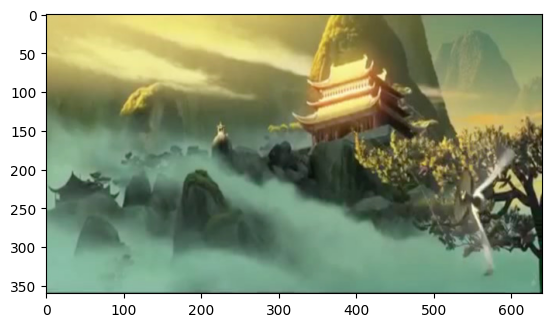

In [94]:
# Plotting the first frame of the movie without cropping
first_frame = cv2.imread('first_frame_movie.jpg')
first_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
plt.imshow(first_frame)


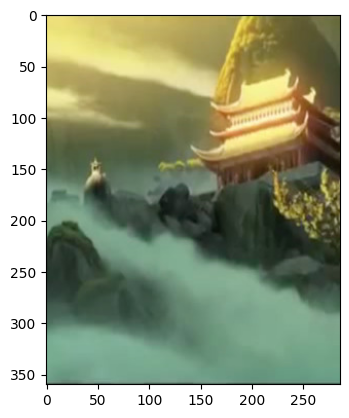

In [99]:
# Crop the first frame to the appropriate size
# 0 --> 145 && 495 --> 640 (will be cropped)
first_frame_cropped = first_frame[0:360, 177:463]
plt.imshow(first_frame_cropped)



**Creating the overlay effect using the first frame of the movie and the cover movie**

As the cover page is 350 x 440, the movie frame has to match it, which can be done through a built in function that resizes an image into given pixel sizes.


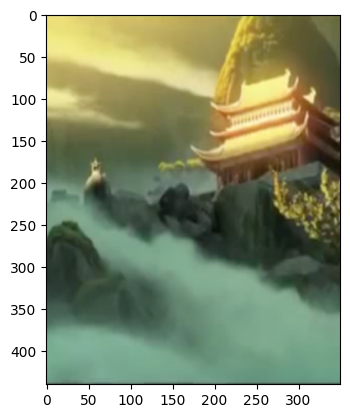

In [103]:
first_frame_resized = cv2.resize(first_frame_cropped, (350, 440))
plt.imshow(first_frame_resized)

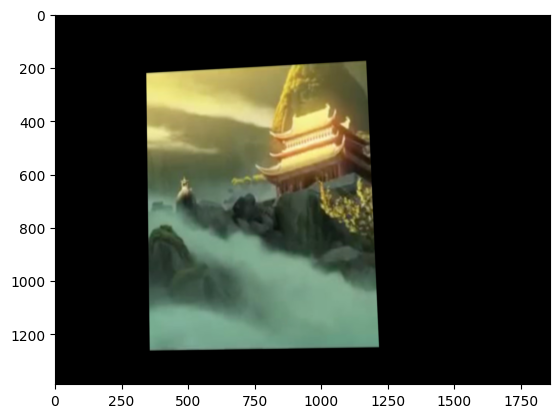

In [107]:
height, width = img_movie.shape[:2]
# Warping
warped_img = cv2.warpPerspective(first_frame_resized, H, (width, height))
plt.imshow(warped_img)

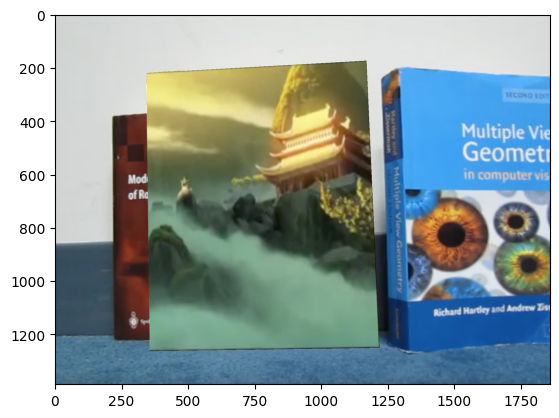

In [109]:
# Create a mask in preparation for the overlay
mask = np.zeros((height, width), dtype=np.uint8)
# Make a polygon with the approximate region for the book white
polygon_region = np.int32(corners_estimated)
cv2.fillConvexPoly(mask, polygon_region, 255)
# Make the book region black, everything else white (invert the mask)
mask_invert = cv2.bitwise_not(mask)
# Bitwise and with the original background
background = cv2.bitwise_and(img_movie, img_movie, mask=mask_invert)
# Add the first frame from the movie
overlay = cv2.add(warped_img, background)
plt.imshow(overlay)

In [117]:
# Entire execution pipeline
def overlay_movies(movie_book, movie_animated):
  # Capture both movies
  backgroud = cv2.VideoCapture(movie_book)
  book_overlay = cv2.VideoCapture(movie_animated)
  # Create instance for output movie
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  # Background and height are defined by those of the movie featuring the books
  # FPS as well
  height = int(backgroud.get(cv2.CAP_PROP_FRAME_HEIGHT))
  width = int(backgroud.get(cv2.CAP_PROP_FRAME_WIDTH))
  fps = backgroud.get(cv2.CAP_PROP_FPS)
  output = cv2.VideoWriter('AR_movie.mp4', fourcc, fps, (width, height))
  # Template for the book's cover
  img_grayscale = cv2.imread('cv_cover.jpg', cv2.IMREAD_GRAYSCALE)
  sift_outcome = SIFT(img_grayscale)
  image_detected_blobs_A = sift_outcome[0]
  keypoints_A = sift_outcome[1]
  descriptors_A = sift_outcome[2]
  # So long as both videos are playing
  while True:
    alive_background, frame_background = backgroud.read()
    alive_overlay, frame_overlay = book_overlay.read()
    # One of the two movies (or both) has ended
    if not alive_background or not alive_overlay:
      break
    # Convert to grayscale
    frame_background_grayscale = cv2.cvtColor(frame_background, cv2.COLOR_BGR2GRAY)
    # SIFT
    sift_outcome_B = SIFT(frame_background_grayscale)
    image_detected_blobs_B = sift_outcome_B[0]
    keypoints_B = sift_outcome_B[1]
    descriptors_B = sift_outcome_B[2]
    # Brute force detector
    brute_force_outcome = brute_force(img_grayscale, keypoints_A, descriptors_A, frame_background_grayscale, keypoints_B, descriptors_B)
    # Compute homography parameters
    H, points_A, points_B =compute_homography(brute_force_outcome[1], keypoints_A, keypoints_B)
    # Find corner boundaries of the book at current frame
    corners, corners_estimated = detect_corners_from_homography(H)
    # Crop movie frame appropriately
    frame_overlay_cropped = frame_overlay[0:360, 177:463]
    # Resize movie frame
    frame_overlay_resized = cv2.resize(frame_overlay_cropped, (350, 440))
    height, width = frame_background_grayscale.shape[:2]
    # Warping
    warped_img = cv2.warpPerspective(frame_overlay_resized, H, (width, height))
    # Create a mask in preparation for the overlay
    mask = np.zeros((height, width), dtype=np.uint8)
    # Make a polygon with the approximate region for the book white
    polygon_region = np.int32(corners_estimated)
    cv2.fillConvexPoly(mask, polygon_region, 255)
    # Make the book region black, everything else white (invert the mask)
    mask_invert = cv2.bitwise_not(mask)
    # Bitwise and with the original background
    background_frame = cv2.bitwise_and(frame_background, frame_background, mask=mask_invert)
    # Add the first frame from the movie
    overlay_frame = cv2.add(warped_img, background_frame)
    output.write(overlay_frame)
  backgroud.release()
  book_overlay.release()
  output.release()

In [120]:
output_video = overlay_movies('book.mov', 'ar_source.mov')

In [115]:
pip install moviepy

In [121]:
from moviepy.editor import VideoFileClip
silent_video = VideoFileClip('AR_movie.mp4')
audio_source = VideoFileClip('ar_source.mov')
extracted = audio_source.audio
video = silent_video.set_audio(extracted)
video.write_videofile('AR_movie_final.mp4', codec='libx264', audio_codec='aac')

Moviepy - Building video AR_movie_final.mp4.
MoviePy - Writing audio in AR_movie_finalTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video AR_movie_final.mp4



Moviepy - Done !
Moviepy - video ready AR_movie_final.mp4
